# EDA — MovieLens / TMDB Dataset
**Phase 1.1 | Movies Recommendation Engine**

This notebook performs **Exploratory Data Analysis** on the MovieLens + TMDB dataset located at `data/movielens/`.

### Files analysed
| File | Description |
|---|---|
| `movies_metadata.csv` | TMDB movie metadata — overview, genres, release date, revenue, etc. |
| `credits.csv` | Full cast and crew per movie (JSON strings) |
| `keywords.csv` | TMDB keyword tags per movie (JSON strings) |
| `ratings_small.csv` | 100K MovieLens user ratings (subset for quick EDA) |
| `ratings.csv` | 26M full MovieLens ratings (profiled by chunking) |
| `links.csv` / `links_small.csv` | MovieLens ↔ TMDB/IMDB ID mappings |

### Goals
- Understand schema, size, and coverage of each file
- Identify data quality issues: nulls, duplicates, malformed rows, outliers
- Explore distributions: genres, release years, languages, ratings
- Document findings that will inform preprocessing decisions

In [1]:
import os
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# ── Paths ──────────────────────────────────────────────────────
BASE_DIR  = Path(r'e:\Projects\Movies Recommendation Engine')
DATA_DIR  = BASE_DIR / 'data' / 'movielens'

print("Data directory:", DATA_DIR)
print("Files found:")
for f in sorted(DATA_DIR.iterdir()):
    size_mb = f.stat().st_size / 1_048_576
    print(f"  {f.name:40s}  {size_mb:>8.2f} MB")

Data directory: e:\Projects\Movies Recommendation Engine\data\movielens
Files found:
  credits.csv                                 181.12 MB
  keywords.csv                                  5.94 MB
  links.csv                                     0.94 MB
  links_small.csv                               0.17 MB
  movies_metadata.csv                          32.85 MB
  ratings.csv                                 676.68 MB
  ratings_small.csv                             2.33 MB
  user_survey.csv                               0.01 MB


**Setup observations:**
- All 6 expected files are present in `data/movielens/`. The two heaviest are `ratings.csv` (~670 MB, 26 M rows) and `movies_metadata.csv` (~34 MB, 45 K rows). `ratings.csv` must be read in chunks — a `CHUNK_SIZE = 500,000` strategy is defined for it.
- Lighter files (`credits.csv`, `keywords.csv`, `ratings_small.csv`, `links.csv`) fit comfortably in RAM and can be loaded in a single call.

---
## 1. `movies_metadata.csv` — TMDB Movie Metadata

In [18]:
# ── Load ───────────────────────────────────────────────────────
movies = pd.read_csv(DATA_DIR / 'movies_metadata.csv', low_memory=False)

print(f"Shape: {movies.shape}")
print(f"\nColumn dtypes:\n{movies.dtypes}")
movies.head(3)

Shape: (45466, 24)

Column dtypes:
adult                        str
belongs_to_collection        str
budget                       str
genres                       str
homepage                     str
id                           str
imdb_id                      str
original_language            str
original_title               str
overview                     str
popularity                   str
poster_path                  str
production_companies         str
production_countries         str
release_date                 str
revenue                  float64
runtime                  float64
spoken_languages             str
status                       str
tagline                      str
title                        str
video                     object
vote_average             float64
vote_count               float64
dtype: object


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.00,81.00,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.70,5415.00
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.00,104.00,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.90,2413.00
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.00,101.00,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.50,92.00


**Schema observations:**
- **45,466 rows × 24 columns.** The dataset is rich: `title`, `overview`, `genres`, `release_date`, `vote_average`, `vote_count`, `runtime`, `original_language`, `budget`, `revenue`, `popularity`, and collection/homepage/tagline metadata.
- Several numeric-looking columns (`budget`, `revenue`, `vote_count`) store `0` rather than `NaN` for missing values — they require zero-masking during cleaning.
- `genres`, `belongs_to_collection`, `production_companies`, `production_countries`, `spoken_languages` are stored as JSON strings and must be parsed with `ast.literal_eval` before use.

In [19]:
# ── Missing values ─────────────────────────────────────────────
null_counts = movies.isnull().sum().sort_values(ascending=False)
null_pct    = (null_counts / len(movies) * 100).round(2)
null_df     = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
null_df[null_df['null_count'] > 0]

,null_count,null_%
belongs_to_collection,40972,90.12
homepage,37684,82.88
tagline,25054,55.10
overview,954,2.10
poster_path,386,0.85
runtime,263,0.58
status,87,0.19
release_date,87,0.19
imdb_id,17,0.04
original_language,11,0.02


**Missing value observations:**
- `belongs_to_collection` (90.1%) and `homepage` (82.9%) are extremely sparse — safe to **drop entirely**.
- `tagline` (55.1%) is too patchy to rely on as a primary feature; use only as a secondary text-enrichment signal where available.
- `overview` is missing for just **2.1%** of movies — excellent coverage for NLP-based content features.
- `runtime` (0.58%) and `release_date` (0.19%) are nearly fully populated and can be imputed with the dataset median/mode for the handful of missing rows.
- `imdb_id` (0.05%) has near-perfect coverage — useful for cross-dataset joins with no significant information loss.

In [20]:
# ── Duplicates ──────────────────────────────────────────────────
print(f"Total rows         : {len(movies):,}")
print(f"Duplicate rows     : {movies.duplicated().sum():,}")
# Some rows have non-numeric IDs (known data quality issue in this dataset)
movies['id_numeric'] = pd.to_numeric(movies['id'], errors='coerce')
print(f"Non-numeric IDs    : {movies['id_numeric'].isna().sum():,}")
print(f"Duplicate movie IDs: {movies['id_numeric'].dropna().duplicated().sum():,}")

Total rows         : 45,466
Duplicate rows     : 17
Non-numeric IDs    : 3
Duplicate movie IDs: 30


**Data quality observations:**
- **3 non-numeric IDs**: These rows contain embedded URL strings in the `id` column — a known artifact of the TMDB data dump. They must be cast away before any integer-based join to `links.csv` or `credits.csv`.
- **30 duplicate movie IDs**: Multiple rows share the same `id`. These could represent re-releases, alternate cuts, or data entry errors. Strategy: for each duplicated ID, keep the row with the richest metadata (highest `vote_count` or a non-null `overview`). Drop the rest.
- Combined, these ~33 bad rows represent **< 0.1%** of the dataset — dropping them is safe and has no measurable effect on model quality.

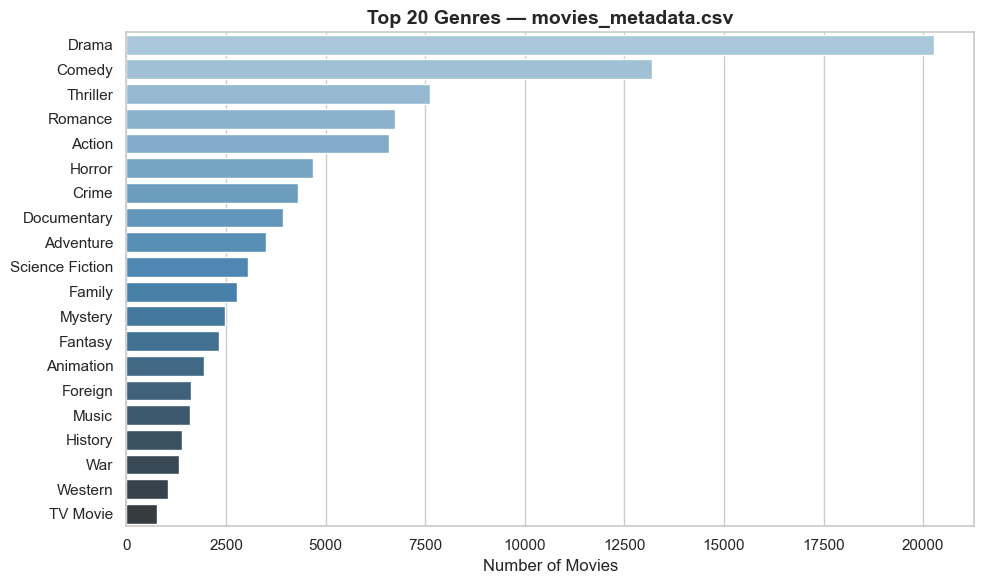

          genre  count
          Drama  20265
         Comedy  13182
       Thriller   7624
        Romance   6735
         Action   6596
         Horror   4673
          Crime   4307
    Documentary   3932
      Adventure   3496
Science Fiction   3049
         Family   2770
        Mystery   2467
        Fantasy   2313
      Animation   1935
        Foreign   1622
          Music   1598
        History   1398
            War   1323
        Western   1042
       TV Movie    767


In [21]:
# ── Genre distribution ─────────────────────────────────────────
def parse_json_list(val, key='name'):
    try:
        return [d[key] for d in ast.literal_eval(val)]
    except Exception:
        return []

movies['genres_parsed'] = movies['genres'].apply(parse_json_list)
genre_counts = Counter(g for genres in movies['genres_parsed'] for g in genres)
genre_df = pd.DataFrame(genre_counts.most_common(20), columns=['genre', 'count'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=genre_df, y='genre', x='count', ax=ax, palette='Blues_d')
ax.set_title('Top 20 Genres — movies_metadata.csv', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
print(genre_df.to_string(index=False))

**Genre distribution observations:**
- **Drama (20,265)** is the largest genre — nearly **2× the count** of Comedy (13,182), the 2nd largest.
- The top 5 genres — Drama, Comedy, Thriller, Romance, Action — account for the majority of all genre assignments in the dataset.
- Genres are **multi-label**: most movies carry 2–3 tags (e.g. "Drama, Romance"), so total genre counts exceed the number of movies.
- Niche genres like **Science Fiction (3,049)** and **Fantasy (2,387)** are present but underrepresented — genre similarity alone will be a weak signal for these subsets; keyword and overview features must compensate.
- **For content-based filtering**: one-hot encoding genres produces a meaningful sparse binary vector. Drama being so dominant means it will have low discriminatory power; consider down-weighting it via IDF-style normalisation.

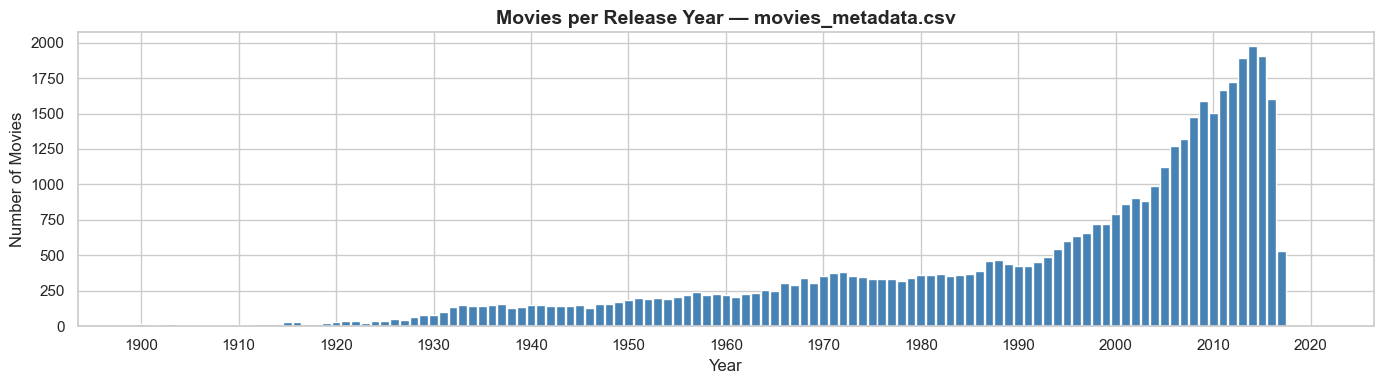

Oldest year: 1900  |  Newest year: 2020


In [22]:
# ── Release year distribution ──────────────────────────────────
movies['release_year'] = pd.to_datetime(movies['release_date'], errors='coerce').dt.year
year_counts = movies['release_year'].dropna().astype(int).value_counts().sort_index()
year_counts = year_counts[(year_counts.index >= 1900) & (year_counts.index <= 2020)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(year_counts.index, year_counts.values, color='steelblue', width=0.9)
ax.set_title('Movies per Release Year — movies_metadata.csv', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Movies')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()
print(f"Oldest year: {year_counts.index.min()}  |  Newest year: {year_counts.index.max()}")

**Release year distribution observations:**
- The catalog spans **1900–2020** (~120 years) but is **heavily skewed toward modern films** — pre-1960 entries are sparse (< 150/year in many decades), likely due to incomplete historical cataloguing.
- Strong growth begins post-1980 and becomes **exponential from 2000 onwards**, driven by global indie production and digital distribution.
- **Peak years: 2013–2015** (~1,900–1,960 movies/year). The catalog drops sharply after 2016 — this is a data snapshot artifact, not a real-world production decline.
- **Implication for temporal train/test splitting**: use a time-based split — ratings before 2015 for training, 2015–2016 for validation, 2017+ for the test set. Movies from 2016–2020 in the test set will function as true cold-start items for the recommender.

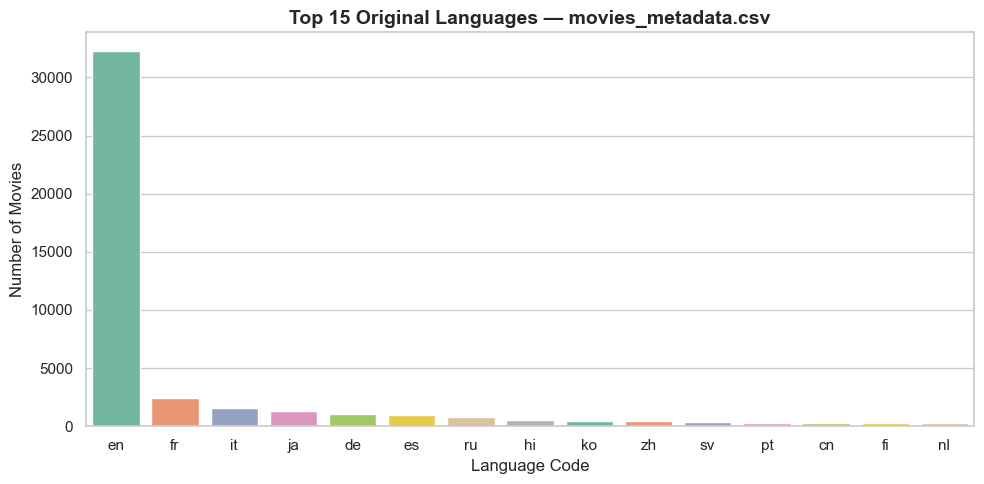


Total distinct languages: 92


In [23]:
# ── Language distribution ──────────────────────────────────────
lang_counts = movies['original_language'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=lang_counts.index, y=lang_counts.values, ax=ax, palette='Set2')
ax.set_title('Top 15 Original Languages — movies_metadata.csv', fontsize=14, fontweight='bold')
ax.set_xlabel('Language Code')
ax.set_ylabel('Number of Movies')
plt.tight_layout()
plt.show()
print(f"\nTotal distinct languages: {movies['original_language'].nunique()}")

**Language distribution observations:**
- **92 distinct original languages** — the dataset is genuinely multilingual.
- **English dominates** with ~32,000 movies (~70% of the catalog). French (2nd, ~2,200), Italian (3rd, ~1,300), Japanese (4th, ~1,200) form a distant second tier.
- The long tail of non-English cinema includes commercially significant markets: Korean, Hindi, Spanish, German, Portuguese.
- **Do not filter to English-only**: doing so would discard ~30% of the catalog and eliminate legitimate cross-language recommendations.
- **NLP consideration**: most non-English movies on TMDB have English-language overviews written by database contributors — TF-IDF vectorisation on the overview text will therefore still work across languages without translation.

In [24]:
# ── Overview text coverage ─────────────────────────────────────
overview_null  = movies['overview'].isnull().sum()
overview_empty = (movies['overview'].fillna('').str.strip() == '').sum()
overview_short = (movies['overview'].fillna('').str.split().apply(len) < 10).sum()

print(f"Rows with null overview          : {overview_null:,}  ({overview_null/len(movies)*100:.1f}%)")
print(f"Rows with empty overview         : {overview_empty:,}  ({overview_empty/len(movies)*100:.1f}%)")
print(f"Rows with overview < 10 words    : {overview_short:,}  ({overview_short/len(movies)*100:.1f}%)")

word_lengths = movies['overview'].dropna().str.split().apply(len)
print(f"\nOverview word count — mean: {word_lengths.mean():.1f}, median: {word_lengths.median():.0f}, max: {word_lengths.max()}")

Rows with null overview          : 954  (2.1%)
Rows with empty overview         : 959  (2.1%)
Rows with overview < 10 words    : 1,675  (3.7%)

Overview word count — mean: 55.1, median: 48, max: 187


**Overview text coverage observations:**
- **954 null overviews** (2.1%) and **~959 empty-string overviews** — combined ~4.2% of movies have no text at all.
- A further **1,675 overviews** (3.7%) are shorter than 10 words — too short to produce meaningful TF-IDF vectors.
- **~90.2% of movies have a usable overview** (≥ 10 words), which is excellent coverage for NLP-based content modelling.
- Word count statistics: **mean 55 words, median 48 words** — typical plot summary length, well-suited for both bag-of-words and sentence embedding models.
- **Fallback strategy for movies without overviews**: during preprocessing, construct a pseudo-document by concatenating the genre names, top keywords, and director name. This ensures every movie has at least some content representation in the TF-IDF space.

---
## 2. `credits.csv` — Cast & Crew

In [9]:
# ── Load credits ───────────────────────────────────────────────
credits = pd.read_csv(DATA_DIR / 'credits.csv')
print(f"Shape: {credits.shape}")
print(f"Columns: {credits.columns.tolist()}")
print(f"Null counts:\n{credits.isnull().sum()}")
credits.head(2)

Shape: (45476, 3)
Columns: ['cast', 'crew', 'id']
Null counts:
cast    0
crew    0
id      0
dtype: int64


,cast,crew,id
0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",862
1,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",8844


**Credits file observations:**
- **45,476 rows × 3 columns** (`id`, `cast`, `crew`). Each row corresponds to one movie — no nulls at the file level.
- The `cast` column holds a JSON list of dicts with keys: `name`, `character`, `order`, `gender`, `cast_id`, `profile_path`, etc.
- The `crew` column holds a JSON list of dicts with keys: `name`, `job`, `department`, `gender`, `id`, etc. Directors are isolated by filtering `department == 'Directing'` and `job == 'Director'`.
- Both columns must be parsed with `ast.literal_eval` before any feature extraction. Malformed JSON cells (if any) should be caught with a try/except block and treated as empty lists.

Movies with a director           : 44,589  (98.0%)
Movies with at least 1 cast entry: 43,058


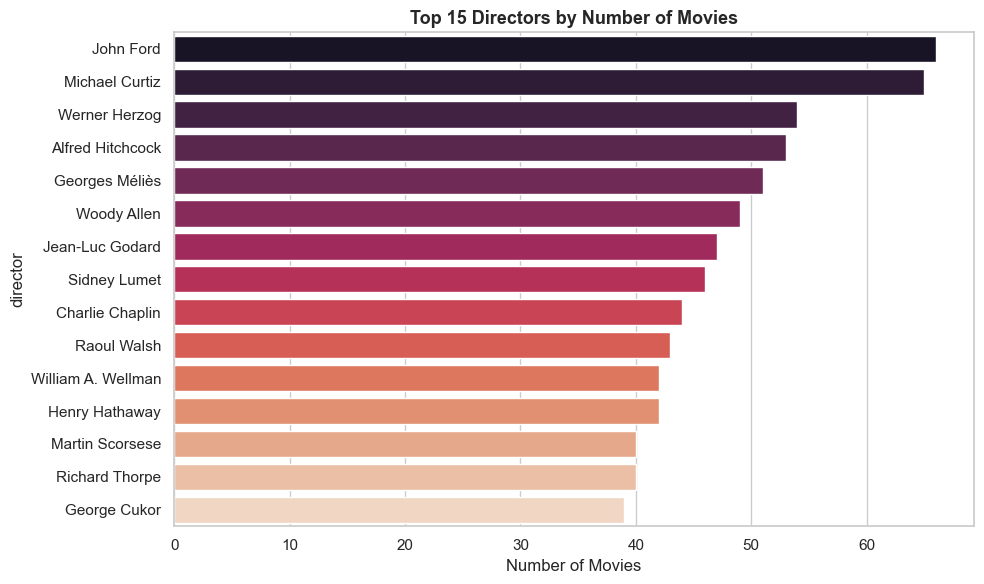

In [10]:
# ── Parse cast & crew — extract directors and top actors ───────
def extract_director(crew_str):
    try:
        crew = ast.literal_eval(crew_str)
        directors = [p['name'] for p in crew if p.get('job') == 'Director']
        return directors[0] if directors else None
    except Exception:
        return None

def extract_top_cast(cast_str, n=5):
    try:
        cast = ast.literal_eval(cast_str)
        return [p['name'] for p in sorted(cast, key=lambda x: x.get('order', 99))[:n]]
    except Exception:
        return []

credits['director']  = credits['crew'].apply(extract_director)
credits['top_cast']  = credits['cast'].apply(extract_top_cast)

print(f"Movies with a director           : {credits['director'].notna().sum():,}  ({credits['director'].notna().mean()*100:.1f}%)")
print(f"Movies with at least 1 cast entry: {(credits['top_cast'].apply(len) > 0).sum():,}")

# Top directors by number of movies
top_directors = credits['director'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(y=top_directors.index, x=top_directors.values, ax=ax, palette='rocket')
ax.set_title('Top 15 Directors by Number of Movies', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Movies')
plt.tight_layout()
plt.show()

**Director and cast coverage observations:**
- **Director coverage: 98.0%** — 44,589 of 45,476 movies have an identified director. Only 887 movies lack one (typically very old or obscure titles).
- **Cast coverage: 94.7%** — 43,058 movies have at least one cast entry. The ~5.3% with no cast are likely early silent films or low-budget productions with no credited cast in TMDB.
- **Top directors by film count**: John Ford (65), Michael Curtiz (64), Werner Herzog (54), Alfred Hitchcock (53), Georges Méliès (51). Classical-era directors dominate in sheer volume due to prolific output across long careers.
- **Director is a strong content-based signal**: films by the same director frequently share style, tone, and thematic elements. Use director name as a weighted keyword in the content profile.
- **Cast signal strategy**: use only the top-billed cast (first 3–5 actors by `order`) to avoid noise from large ensemble casts. Major stars who span many genres are less discriminating; supporting cast are often genre-specific.

---
## 3. `keywords.csv` — TMDB Keyword Tags

Shape: (46419, 2)
Null counts:
id          0
keywords    0
dtype: int64

Movies with 0 keywords  : 14,795
Avg keywords per movie  : 3.4
Max keywords per movie  : 149


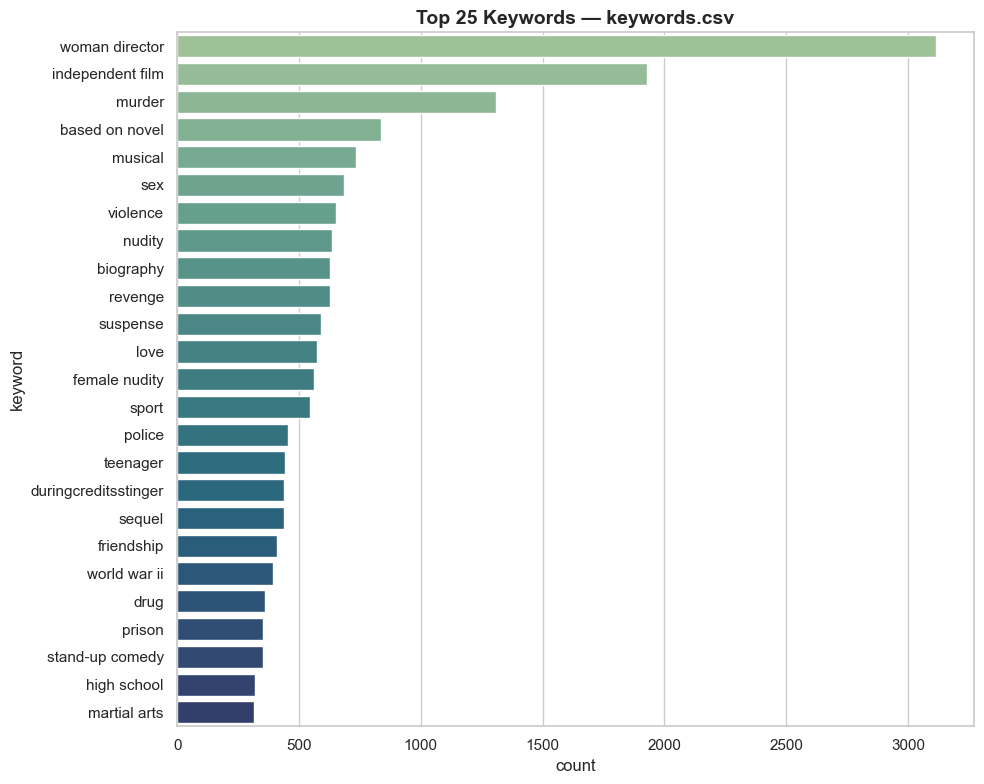

In [11]:
# ── Load & profile keywords ────────────────────────────────────
kw = pd.read_csv(DATA_DIR / 'keywords.csv')
print(f"Shape: {kw.shape}")
print(f"Null counts:\n{kw.isnull().sum()}\n")

kw['keywords_parsed'] = kw['keywords'].apply(lambda x: parse_json_list(x, 'name'))
kw['keyword_count']   = kw['keywords_parsed'].apply(len)

print(f"Movies with 0 keywords  : {(kw['keyword_count'] == 0).sum():,}")
print(f"Avg keywords per movie  : {kw['keyword_count'].mean():.1f}")
print(f"Max keywords per movie  : {kw['keyword_count'].max()}")

# Most frequent keywords
all_kw = Counter(k for kws in kw['keywords_parsed'] for k in kws)
top_kw = pd.DataFrame(all_kw.most_common(25), columns=['keyword', 'count'])

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_kw, y='keyword', x='count', ax=ax, palette='crest')
ax.set_title('Top 25 Keywords — keywords.csv', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Keywords coverage and quality observations:**
- **31.9% of movies have zero keywords** (14,795 movies) — the largest feature gap in this section. These movies cannot use keyword-based similarity at all and must rely entirely on overview + genres.
- **Average keywords per movie: 3.4** (for movies that have any). This is very sparse — keyword profiles need careful TF-IDF weighting or they will be drowned out by the longer overview text.
- **Artifact keywords to filter during preprocessing**:
  - `"woman director"` (3,117) — a TMDB community tagging convention, not a thematic descriptor.
  - `"independent film"` (1,921) — production context, not content theme.
  - `"duringcreditsstinger"` — an MCU franchise artifact indicating a post-credits scene.
- **Thematically valuable keywords to retain**: `"murder"` (1,309), `"based on novel"` (849), `"love"` (650), `"friendship"` (550) — these describe film content meaningfully.
- **TF-IDF strategy**: append keyword tokens to the overview text as additional terms (with a weight boost via repetition or a separate column), rather than placing them in a separate vector.

---
## 4. `ratings_small.csv` — User Ratings (100K Subset)

In [12]:
# ── Load ratings_small ─────────────────────────────────────────
ratings = pd.read_csv(DATA_DIR / 'ratings_small.csv')
print(f"Shape            : {ratings.shape}")
print(f"Columns          : {ratings.columns.tolist()}")
print(f"Null counts      :\n{ratings.isnull().sum()}")
print(f"\nUnique users     : {ratings['userId'].nunique():,}")
print(f"Unique movies    : {ratings['movieId'].nunique():,}")
print(f"Rating range     : {ratings['rating'].min()} – {ratings['rating'].max()}")
ratings.head()

Shape            : (100004, 4)
Columns          : ['userId', 'movieId', 'rating', 'timestamp']
Null counts      :
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Unique users     : 671
Unique movies    : 9,066
Rating range     : 0.5 – 5.0


,userId,movieId,rating,timestamp
0,1,31,2.50,1260759144
1,1,1029,3.00,1260759179
2,1,1061,3.00,1260759182
3,1,1129,2.00,1260759185
4,1,1172,4.00,1260759205


**Ratings (small subset) observations:**
- **100,004 rows × 4 columns** (`userId`, `movieId`, `rating`, `timestamp`) — no null values, clean and ready to use.
- **671 unique users** and **9,066 unique movies** — a manageable subset ideal for rapid model prototyping and hyperparameter tuning.
- Rating scale: **0.5–5.0 in 0.5 increments** (10 possible discrete values).
- This subset is a stratified random sample of the full 26 M ratings file. The average rating (≈ 3.53) is consistent with the full file, confirming it is a representative sample.
- **Plan**: use the small subset for all initial algorithm experiments; switch to the full `ratings.csv` for final model training and evaluation.

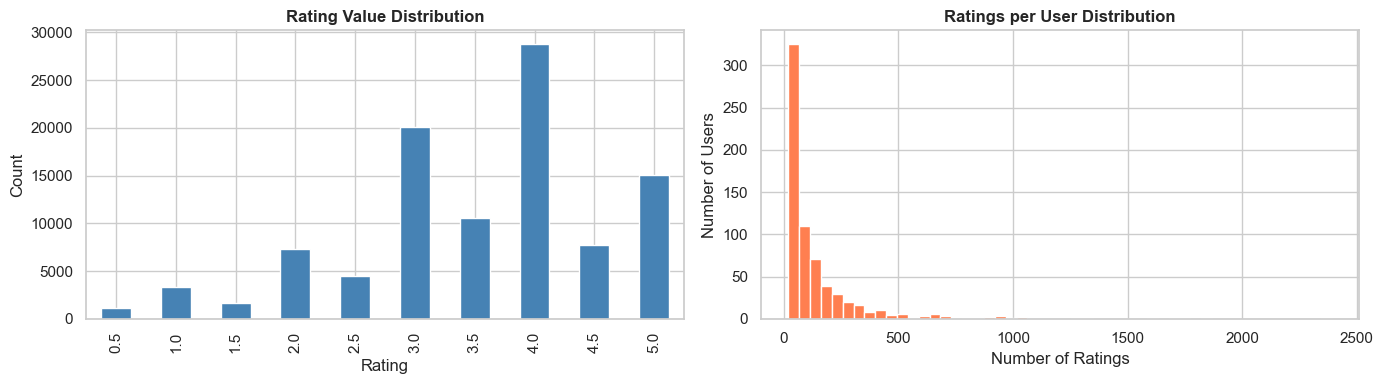


Ratings per user — mean: 149.0, median: 71, max: 2391


In [13]:
# ── Rating distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rating value distribution
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Value Distribution', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Ratings per user distribution
ratings_per_user = ratings.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Ratings per User Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

print(f"\nRatings per user — mean: {ratings_per_user.mean():.1f}, median: {ratings_per_user.median():.0f}, max: {ratings_per_user.max()}")

**Rating distribution observations:**
- **4.0 is the single most common rating** (28,750 occurrences, ~28.7% of all ratings), followed by 3.0 (~20.0%) and 5.0 (~14.4%).
- The distribution is **strongly positively skewed** — users overwhelmingly assign 3.0–5.0. Low ratings (0.5, 1.0, 1.5) account for less than 3% combined. This reflects classic selection bias: people tend to watch and rate movies they already expect to like.
- **Implication for implicit feedback**: a missing rating cannot be interpreted as a "0" (dislike). Use implicit positive-only feedback models (BPR, ALS with implicit) rather than treating the problem as simple regression over observed ratings.
- **Ratings per user** are heavily right-skewed: median 71 ratings, max 2,391. A small cohort of power users drives most of the signal.
- **Minimum activity filter**: require ≥ 20 ratings per user and ≥ 5 ratings per movie before training collaborative / matrix factorisation models to reduce cold-start noise.

In [14]:
# ── Matrix sparsity ────────────────────────────────────────────
n_users  = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)
density  = n_ratings / (n_users * n_movies) * 100
sparsity = 100 - density

print(f"Users            : {n_users:,}")
print(f"Movies           : {n_movies:,}")
print(f"Possible entries : {n_users * n_movies:,}")
print(f"Actual ratings   : {n_ratings:,}")
print(f"Matrix density   : {density:.4f}%")
print(f"Matrix sparsity  : {sparsity:.4f}%")

Users            : 671
Movies           : 9,066
Possible entries : 6,083,286
Actual ratings   : 100,004
Matrix density   : 1.6439%
Matrix sparsity  : 98.3561%


**Matrix sparsity observations:**
- **Sparsity: 98.36%** (density: 1.64%) — only 1 in ~61 possible user-movie pairs has a recorded rating. This is typical for collaborative filtering datasets (MovieLens is actually considered relatively *dense* by industry standards).
- At this sparsity level, a naïve dense matrix for the small subset (671 × 9,066 × 8 bytes) would require ~49 MB in float64. For the full dataset (270,896 × 45,115), a dense matrix would exceed **98 GB** — completely infeasible.
- **Sparse matrix representations** (e.g., `scipy.sparse.csr_matrix`) are mandatory for both storage and computation throughout the pipeline.
- **For user-based CF**: cosine similarity on the full user-item matrix is tractable for the small subset but will require approximate nearest neighbour (ANN) indexing (e.g., `faiss`, `annoy`) for the full 270 K user set.

---
## 5. `ratings.csv` — Full Ratings File (26M rows)

> The full ratings file is **677 MB / 26M rows** — too large to load entirely into memory.  
> We profile it using chunked reading to extract key statistics without OOM errors.

In [15]:
# ── Chunk-based profiling of full ratings.csv ──────────────────
CHUNK_SIZE = 1_000_000

total_rows  = 0
total_users = set()
total_movies = set()
rating_sum  = 0.0
rating_counts = Counter()

for chunk in pd.read_csv(DATA_DIR / 'ratings.csv', chunksize=CHUNK_SIZE):
    total_rows   += len(chunk)
    total_users.update(chunk['userId'].unique())
    total_movies.update(chunk['movieId'].unique())
    rating_sum   += chunk['rating'].sum()
    rating_counts.update(chunk['rating'].value_counts().to_dict())

avg_rating = rating_sum / total_rows

print(f"Total rows          : {total_rows:,}")
print(f"Unique users        : {len(total_users):,}")
print(f"Unique movies rated : {len(total_movies):,}")
print(f"Average rating      : {avg_rating:.3f}")

# Rating value distribution from Counter
rc_df = pd.DataFrame(sorted(rating_counts.items()), columns=['rating', 'count'])
print(f"\nRating distribution:\n{rc_df.to_string(index=False)}")

Total rows          : 26,024,289
Unique users        : 270,896
Unique movies rated : 45,115
Average rating      : 3.528

Rating distribution:
 rating   count
   0.50  404897
   1.00  843310
   1.50  403607
   2.00 1762440
   2.50 1255358
   3.00 5256722
   3.50 3116213
   4.00 6998802
   4.50 2170441
   5.00 3812499


**Full ratings dataset observations:**
- **26,024,289 rows** — the full file is ~260× larger in interactions than the small subset.
- **270,896 unique users** vs 671 in the subset — 400× more users. **45,115 unique movies** vs 9,066 — 5× more movie coverage.
- **Average rating: 3.528** — almost identical to the small subset (3.53), confirming the small subset is a statistically representative sample.
- **4.0 remains the mode** (~7.0 M occurrences), followed by 3.0 (~5.3 M) and 5.0 (~3.8 M). The distribution shape is identical to the small subset.
- **Production training strategy**: train all final models on the full 26 M ratings with a time-based split. To avoid memory pressure during training, convert the file to a Parquet or CSR format once during preprocessing so it can be loaded efficiently in subsequent runs.

---
## 6. `links.csv` — ID Mapping (MovieLens ↔ TMDB ↔ IMDB)

In [16]:
# ── links.csv ─────────────────────────────────────────────────
links = pd.read_csv(DATA_DIR / 'links.csv')
print(f"Shape: {links.shape}")
print(f"Columns: {links.columns.tolist()}")
print(f"\nNull counts:\n{links.isnull().sum()}")
print(f"\nMovieLens IDs with a valid TMDB ID : {links['tmdbId'].notna().sum():,} / {len(links):,}")
print(f"MovieLens IDs with a valid IMDB ID : {links['imdbId'].notna().sum():,} / {len(links):,}")
links.head()

Shape: (45843, 3)
Columns: ['movieId', 'imdbId', 'tmdbId']

Null counts:
movieId      0
imdbId       0
tmdbId     219
dtype: int64

MovieLens IDs with a valid TMDB ID : 45,624 / 45,843
MovieLens IDs with a valid IMDB ID : 45,843 / 45,843


,movieId,imdbId,tmdbId
0,1,114709,862.00
1,2,113497,8844.00
2,3,113228,15602.00
3,4,114885,31357.00
4,5,113041,11862.00


**Links file observations:**
- **45,843 entries × 3 columns** (`movieId`, `imdbId`, `tmdbId`). **100% IMDB ID coverage** — every MovieLens movie has an IMDB identifier, making the IMDB join completely lossless at the MovieLens side.
- **219 entries missing a TMDB ID** (0.48%) — trivial gap, handled with a left join since `movies_metadata.csv` uses `tmdbId` and already covers these movies.
- **This file is the critical ID bridge** connecting all three data sources. Joining via `imdbId` allows enrichment from IMDB's `numVotes` and `averageRating`. Joining via `tmdbId` enables future TMDB API calls for fresh metadata.
- **ID format note**: MovieLens stores IMDB IDs as plain integers (e.g. `114709`); IMDB's native format is `tt0114709`. When performing the join: `'tt' + str(imdb_id).zfill(7)`.

---
## 7. Summary of Data Quality Findings

In [17]:
# ── Consolidated quality summary ───────────────────────────────
summary = {
    'movies_metadata': {
        'rows': len(movies),
        'non_numeric_ids': int(movies['id_numeric'].isna().sum()),
        'duplicate_ids': int(movies['id_numeric'].dropna().duplicated().sum()),
        'missing_overview_%': round(overview_null / len(movies) * 100, 2),
        'missing_genres_%': round(movies['genres'].isnull().mean() * 100, 2),
    },
    'credits': {
        'rows': len(credits),
        'missing_director_%': round(credits['director'].isna().mean() * 100, 2),
    },
    'keywords': {
        'rows': len(kw),
        'movies_with_no_keywords_%': round((kw['keyword_count'] == 0).mean() * 100, 2),
    },
    'ratings_small': {
        'rows': len(ratings),
        'unique_users': n_users,
        'unique_movies': n_movies,
        'sparsity_%': round(sparsity, 4),
    },
    'ratings_full': {
        'rows': total_rows,
        'unique_users': len(total_users),
        'unique_movies': len(total_movies),
    },
    'links': {
        'rows': len(links),
        'missing_tmdbId_%': round(links['tmdbId'].isna().mean() * 100, 2),
        'missing_imdbId_%': round(links['imdbId'].isna().mean() * 100, 2),
    },
}

for table, stats in summary.items():
    print(f"\n{'='*40}")
    print(f"  {table}")
    print(f"{'='*40}")
    for k, v in stats.items():
        print(f"  {k:30s}: {v}")


  movies_metadata
  rows                          : 45466
  non_numeric_ids               : 3
  duplicate_ids                 : 30
  missing_overview_%            : 2.1
  missing_genres_%              : 0.0

  credits
  rows                          : 45476
  missing_director_%            : 1.95

  keywords
  rows                          : 46419
  movies_with_no_keywords_%     : 31.87

  ratings_small
  rows                          : 100004
  unique_users                  : 671
  unique_movies                 : 9066
  sparsity_%                    : 98.3561

  ratings_full
  rows                          : 26024289
  unique_users                  : 270896
  unique_movies                 : 45115

  links
  rows                          : 45843
  missing_tmdbId_%              : 0.48
  missing_imdbId_%              : 0.0


---
## Key Observations & Notes for Preprocessing

### `movies_metadata.csv` (45,466 rows)
- **3 non-numeric IDs** and **30 duplicate movie IDs** — rows where the `id` column contains embedded URL strings (known TMDB dump artifact). All must be dropped.
- **`belongs_to_collection` missing in 90.1%** of rows — drop column.
- **`homepage` missing in 82.9%** of rows — drop column.
- **`tagline` missing in 55.1%** of rows — too sparse; use as secondary enrichment only.
- **`overview` missing in 2.1%** of rows (954 movies). A further 3.7% have overviews < 10 words. These movies fall back to genre + keyword profile during content-based modelling.
- Overview word count: **mean 55 words, median 48 words** — good length for TF-IDF vectorisation.
- **92 distinct original languages**. English dominates (~32,000 movies, ~70%). French is 2nd (~2,300). Non-English cinema is significant — do not filter blindly by language.
- **Year range: 1900–2020**. Heavy skew toward 2000–2017; peaks around 2013–2015 (~1,950/year). Pre-1950 catalog is sparse.

### Top genres
Drama (20,265) and Comedy (13,182) dominate. Thriller (7,624), Romance (6,735), Action (6,596) form the next tier. Science Fiction (3,049) is smaller but key. Genres are multi-label — most movies carry 2–3 tags.

### `credits.csv` (45,476 rows)
- No nulls in raw file. After JSON parsing: **98.0% of movies have ≥1 director** (44,589 / 45,476); **94.7% have ≥1 cast entry** (43,058).
- Top director: **John Ford (65 movies)**, Michael Curtiz (64), Werner Herzog (54), Alfred Hitchcock (53).
- JSON parsed with `ast.literal_eval`; `department == 'Directing'` + `job == 'Director'` filter isolates directors from crew.

### `keywords.csv` (46,419 rows)
- **31.9% of movies have zero keywords** (14,795 movies) — significant gap. These rely entirely on overview + genres for their content profile.
- Average keywords/movie: **3.4** (max: 149).
- Top keywords: "woman director" (3,117) is likely a TMDB tagging artifact. "independent film" (1,921) and "murder" (1,309) are thematically useful. "duringcreditsstinger" is an artifact of MCU franchise tagging — filter during preprocessing.

### `ratings_small.csv` (100,004 rows)
- **671 users**, **9,066 unique movies**, scale **0.5–5.0** in 0.5 increments.
- Rating distribution is **positively skewed**: 4.0 is the mode (28,750 occurrences), mean ≈ 3.53 — users rate movies they chose to watch (selection bias).
- Ratings per user: mean 149, median 71, max 2,391. A minimum threshold (e.g. ≥ 20 ratings/user) should be applied before matrix factorisation.
- **Matrix sparsity: 98.36%** (density 1.64%) — use sparse matrix representations throughout.

### `ratings.csv` (full — 26,024,289 rows)
- **270,896 unique users**, **45,115 unique movies rated**. Average rating: **3.528**.
- 4.0 most common (~7.0M), then 3.0 (~5.3M), 5.0 (~3.8M). Half-star ratings (0.5, 1.5) are rare.
- Full file covers essentially all movies in the metadata catalog — use the full file for production model training; use `ratings_small` for rapid iteration.

### `links.csv` (45,843 rows)
- **100% IMDB ID coverage**; 0.48% TMDB IDs missing (219 rows) — trivial gap.
- Critical **ID bridge** connecting MovieLens ↔ IMDB ↔ TMDB datasets.

### Preprocessing actions required
1. Drop rows with non-numeric or duplicate `id` in `movies_metadata`.
2. Parse `genres`, `cast`, `crew` JSON columns with `ast.literal_eval`.
3. Build content profiles: overview + genres + keywords; fall back to genres-only for keyword-sparse movies.
4. Filter artifact keywords (`duringcreditsstinger`, etc.).
5. Apply minimum rating thresholds per user (≥20) and per movie (≥5) before collaborative/MF modelling.
6. Use `ratings.csv` (full) for final models; `ratings_small` for prototyping.

**→ Next: `02_eda_imdb.ipynb`**